In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [4]:
iris = load_iris()

x=iris.data
y=iris.target

print("X shape : ",x.shape)
print("y shape : ",y.shape)

print("Features : ")
print(iris.feature_names)

print("Classes : ",iris.target_names)

X shape :  (150, 4)
y shape :  (150,)
Features : 
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Classes :  ['setosa' 'versicolor' 'virginica']


In [7]:
print(y)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


In [5]:
df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

df["target"] = iris.target
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


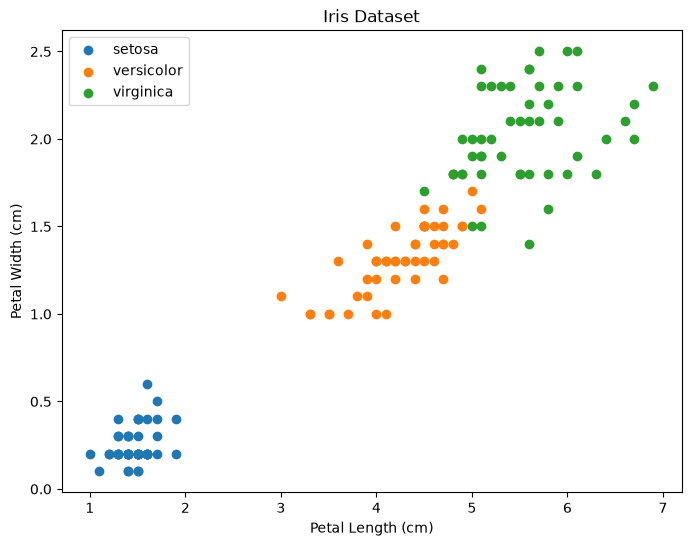

In [10]:
plt.figure(figsize=(8,6))

for i ,name in enumerate (iris.target_names) : 
    plt.scatter(
        x[y == i,2],
        x[y == i,3],
        label = name
    )

plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.title("Iris Dataset")
plt.legend()
plt.show()

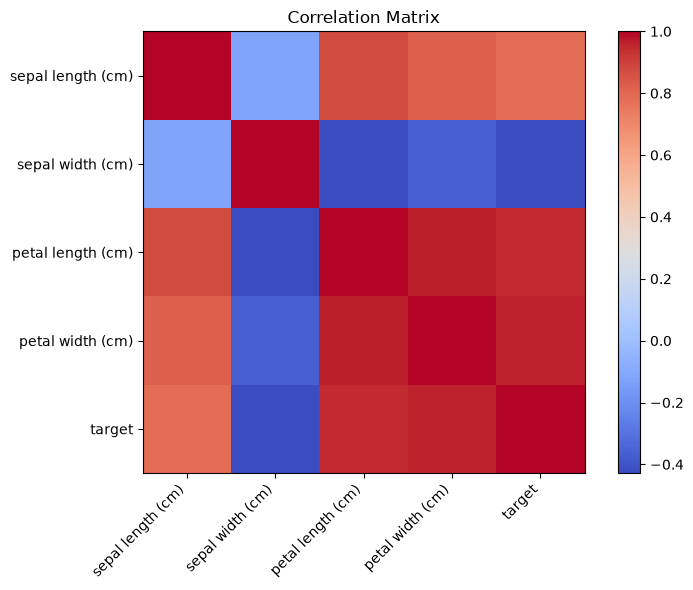

In [14]:
plt.figure(figsize=(8, 6))

correlation = df.corr()

plt.imshow(correlation, cmap="coolwarm")

plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

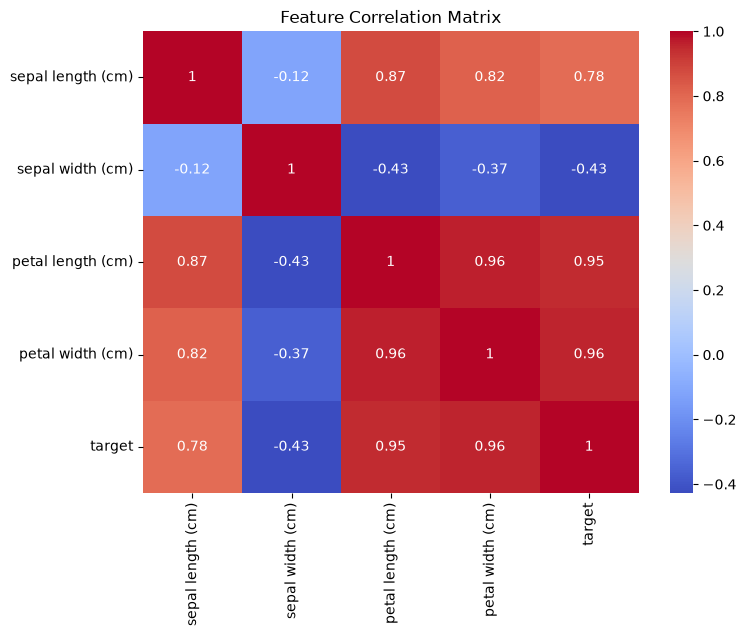

In [15]:
import seaborn as sns

plt.figure(figsize=(8, 6))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlation Matrix")
plt.show()

In [16]:
x=iris.data[:,[2,3]]
y=iris.target

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [18]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(X_train)
x_test_scaled = scaler.transform(X_test)

In [20]:
model = SVC(
    kernel="linear",
    C=1.0
)

model.fit(
    x_train_scaled,
    y_train
)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [21]:
y_pred = model.predict(x_test_scaled)

print(y_pred)

[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 1 2 2 1 0 2 0]


In [22]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)

Accuracy: 0.9333333333333333


In [23]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=iris.target_names
    )
)

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



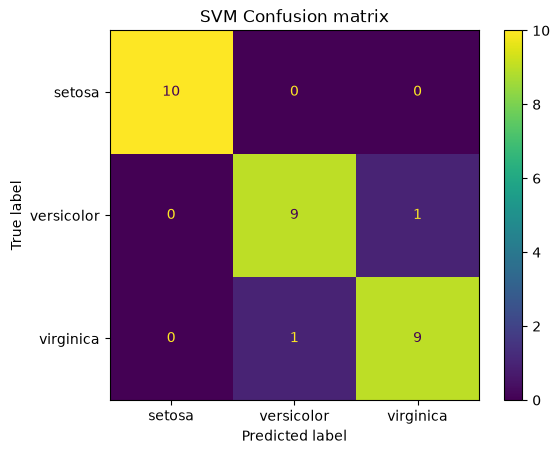

In [24]:
cm = confusion_matrix(
    y_test,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=iris.target_names
)

disp.plot()

plt.title("SVM Confusion matrix")
plt.show()

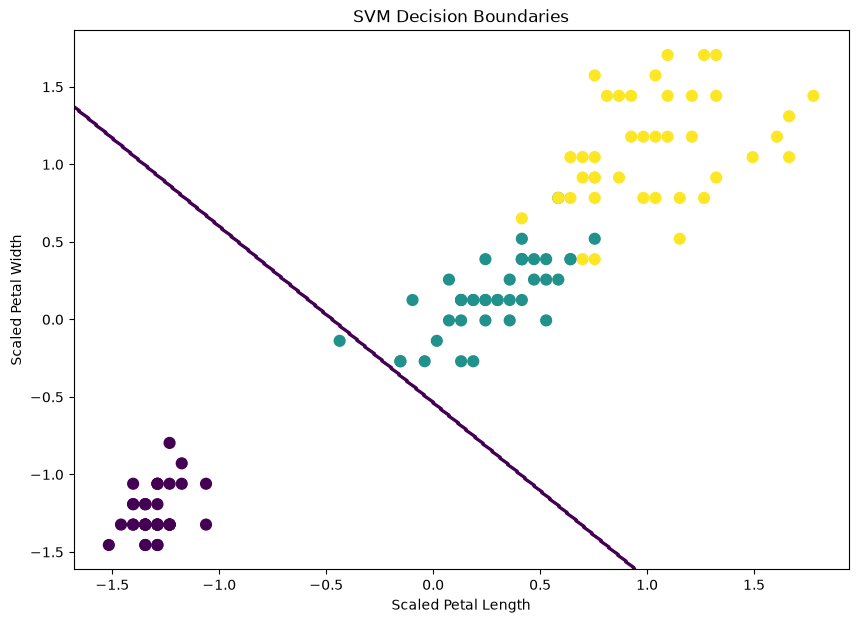

In [26]:
plt.figure(figsize=(10, 7))

plt.scatter(
    x_train_scaled[:, 0],
    x_train_scaled[:, 1],
    c=y_train,
    cmap="viridis",
    s=60
)

ax = plt.gca()

xlim = ax.get_xlim()
ylim = ax.get_ylim()

xx = np.linspace(
    xlim[0],
    xlim[1],
    500
)

yy = np.linspace(
    ylim[0],
    ylim[1],
    500
)

YY, XX = np.meshgrid(
    yy,
    xx
)

xy = np.vstack(
    [
        XX.ravel(),
        YY.ravel()
    ]
).T

Z = model.decision_function(xy)

Z = Z.reshape(
    XX.shape + (3,)
)

for i in range(3):
    plt.contour(
        XX,
        YY,
        Z[:, :, i],
        levels=[0],
        linewidths=2
    )

plt.xlabel("Scaled Petal Length")
plt.ylabel("Scaled Petal Width")
plt.title("SVM Decision Boundaries")
plt.show()

In [27]:
print(model.support_vectors_)

print(
    "Number of support vectors:",
    len(model.support_vectors_)
)

print(
    "Support vectors per class:",
    model.n_support_
)

[[-1.23215924 -0.79659873]
 [-1.06181465 -1.05993716]
 [ 0.41450518  0.38842418]
 [ 0.64163131  0.38842418]
 [-0.15331014 -0.26992188]
 [ 0.58484978  0.78343181]
 [ 0.75519438  0.52009339]
 [ 0.41450518  0.38842418]
 [ 0.47128672  0.38842418]
 [ 0.41450518  0.52009339]
 [ 0.41450518  0.38842418]
 [-0.4372178  -0.13825267]
 [ 0.52806825  0.38842418]
 [ 0.64163131  0.38842418]
 [ 0.41450518  0.6517626 ]
 [ 0.69841284  0.91510102]
 [ 0.75519438  0.38842418]
 [ 0.75519438  0.91510102]
 [ 0.75519438  0.78343181]
 [ 0.75519438  0.91510102]
 [ 0.69841284  0.38842418]
 [ 1.1526651   0.52009339]
 [ 0.64163131  0.78343181]
 [ 0.58484978  0.78343181]]
Number of support vectors: 24
Support vectors per class: [ 2 12 10]


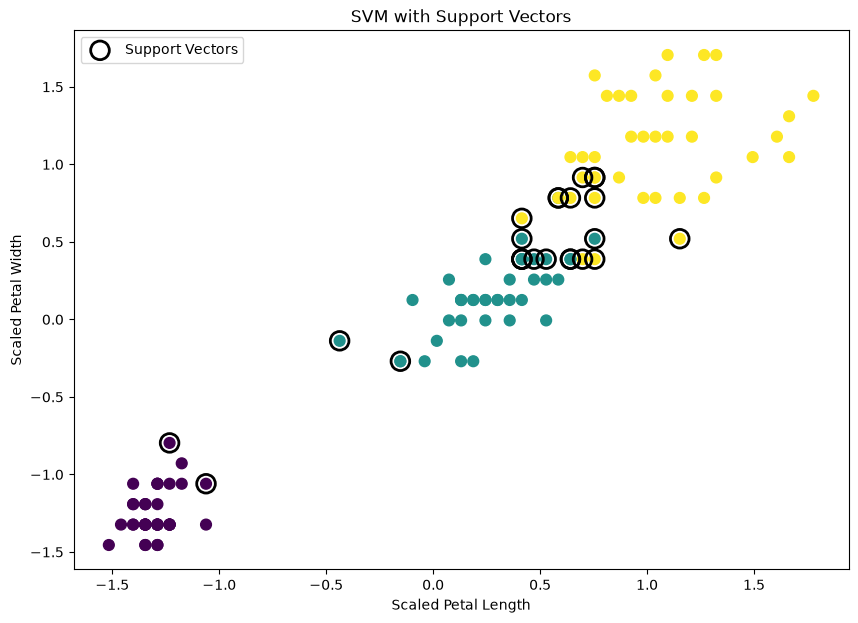

In [28]:
plt.figure(figsize=(10, 7))

plt.scatter(
    x_train_scaled[:, 0],
    x_train_scaled[:, 1],
    c=y_train,
    cmap="viridis",
    s=60
)

plt.scatter(
    model.support_vectors_[:, 0],
    model.support_vectors_[:, 1],
    s=180,
    facecolors="none",
    edgecolors="black",
    linewidths=2,
    label="Support Vectors"
)

plt.xlabel("Scaled Petal Length")
plt.ylabel("Scaled Petal Width")

plt.title(
    "SVM with Support Vectors"
)

plt.legend()

plt.show()

In [29]:
C_values = [0.01, 0.1, 1, 10, 100]

results = []

for c in C_values:

    svm = SVC(
        kernel="linear",
        C=c
    )

    svm.fit(
        x_train_scaled,
        y_train
    )

    prediction = svm.predict(
        x_test_scaled
    )

    acc = accuracy_score(
        y_test,
        prediction
    )

    results.append(
        {
            "C": c,
            "Accuracy": acc
        }
    )

results_df = pd.DataFrame(results)

print(results_df)

        C  Accuracy
0    0.01  0.933333
1    0.10  0.933333
2    1.00  0.933333
3   10.00  0.933333
4  100.00  0.933333


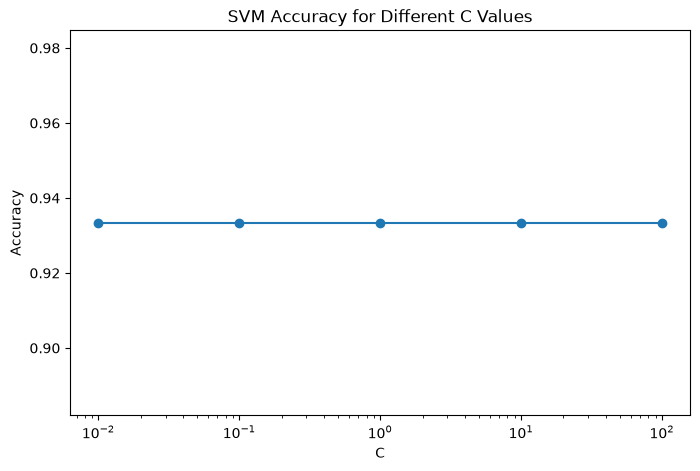

In [30]:
plt.figure(figsize=(8, 5))

plt.plot(
    results_df["C"],
    results_df["Accuracy"],
    marker="o"
)

plt.xscale("log")

plt.xlabel("C")
plt.ylabel("Accuracy")

plt.title(
    "SVM Accuracy for Different C Values"
)

plt.show()